# Logistic Regression: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Logistic Regression** in Python.

### Concept Overview
Models the probability of a binary output classification class using the Sigmoid activation function.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
p = \sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{where} \quad z = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n
$$

### Real-World Analogy
**Analogy:** Deciding whether an email is spam (1) or not spam (0) based on certain keywords.

### Worked Example
**Worked Example:** Predicting customer purchase. Sigmoid converts linear output z = 0.5 into a probability: p = 1 / (1 + e^-0.5) = 0.62. Since 62% is >= 50% default cutoff, predict class 1 (Purchased).

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of customer purchase data
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=500, n_features=2, n_informative=2,
                                  n_redundant=0, n_classes=2, n_clusters_per_class=1,
                                  weights=[0.6, 0.4], class_sep=1.2, random_state=42)
# Scale features artificially to mimic Age and Salary
Age = 20 + X_raw[:, 0] * 8 + 15
Salary = 20000 + X_raw[:, 1] * 35000 + 50000
df = pd.DataFrame({
    'Age': np.round(np.clip(Age, 18, 70), 0),
    'EstimatedSalary': np.round(np.clip(Salary, 15000, 150000), -2),
    'Purchased': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              500 non-null    float64
 1   EstimatedSalary  500 non-null    float64
 2   Purchased        500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
              Age  EstimatedSalary   Purchased
count  500.000000        500.00000  500.000000
mean    44.852000      70012.40000    0.402000
std      7.028292      44268.40849    0.490793
min     21.000000      15000.00000    0.000000
25%     40.000000      21300.00000    0.000000
50%     45.000000      68200.00000    0.000000
75%     49.000000     109525.00000    1.000000
max     67.000000     150000.00000    1.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Duplicate count: 99


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

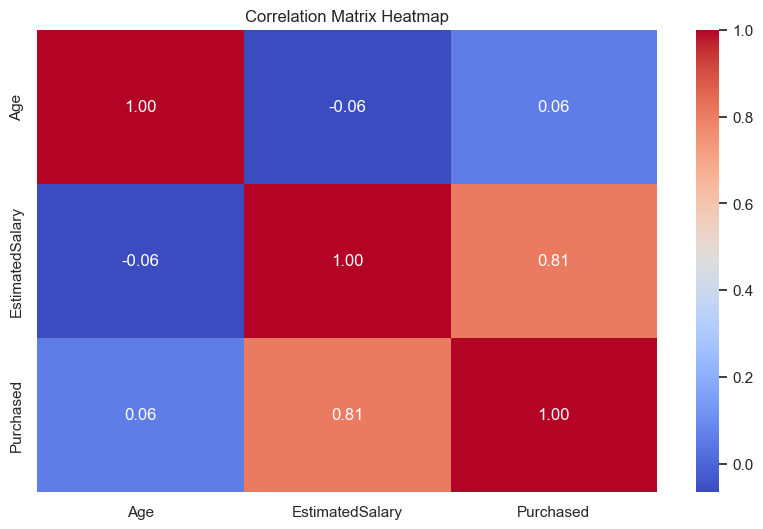

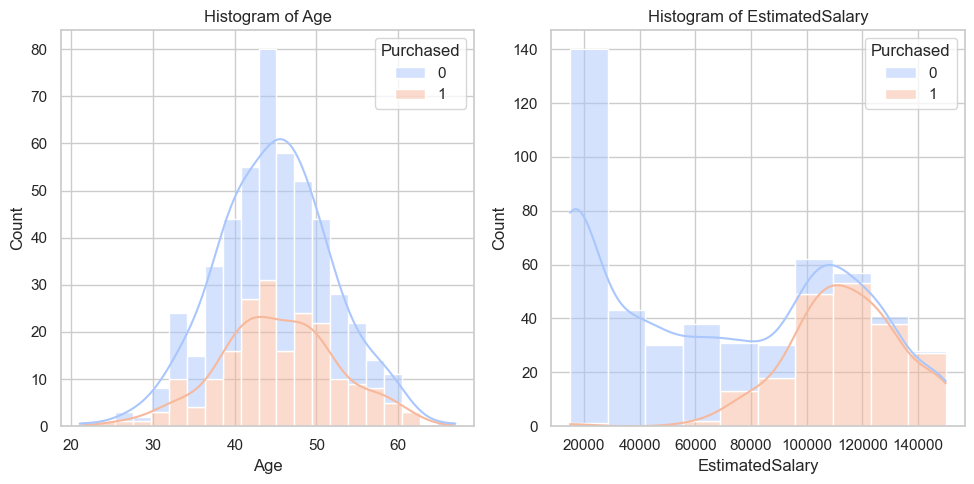

G:\Temp\ipykernel_11532\1348028533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')


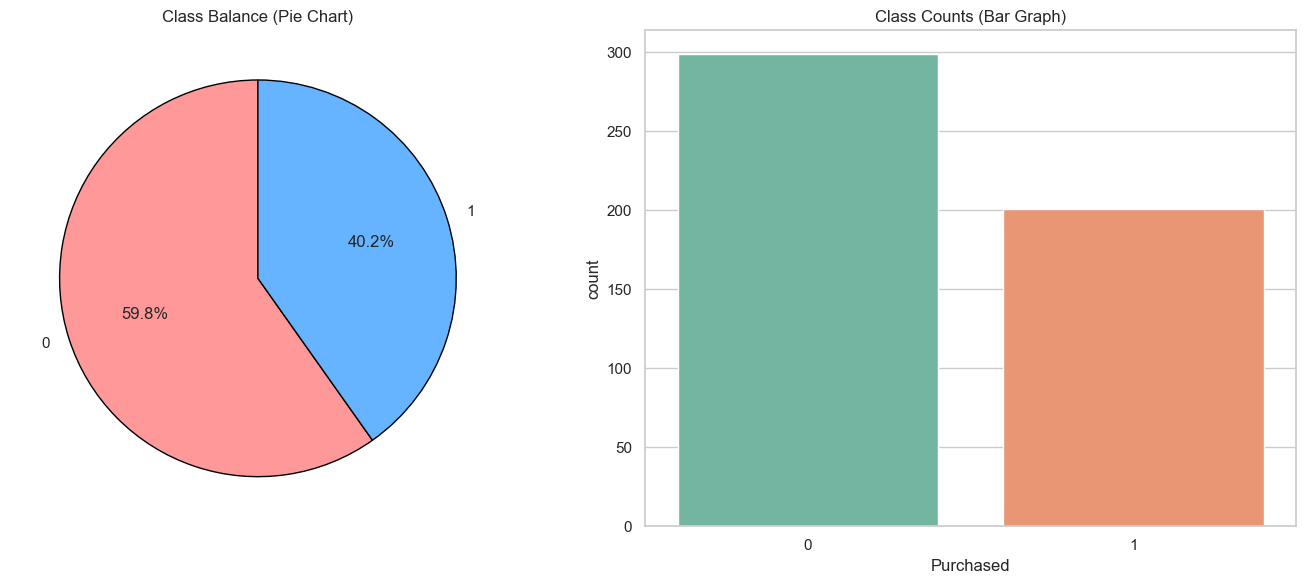

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 1. Feature Histograms (Continuous distributions colored by class)
X_cols = df.columns[:-1]
target_col = df.columns[-1]
fig, axes = plt.subplots(1, len(X_cols), figsize=(5 * len(X_cols), 5))
if len(X_cols) == 1:
    sns.histplot(data=df, x=X_cols[0], hue=target_col, kde=True, ax=axes, multiple='stack', palette='coolwarm')
    axes.set_title(f'Histogram of {X_cols[0]}')
else:
    for idx, col in enumerate(X_cols):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[idx], multiple='stack', palette='coolwarm')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# 2. Class Balance Pie Chart and Bar Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Pie chart
class_counts = df[target_col].value_counts()
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff', '#99ff99'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Class Balance (Pie Chart)')
# Bar chart
sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')
axes[1].set_title('Class Counts (Bar Graph)')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling applied successfully.')

Scaling applied successfully.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (350, 2), Test size: (150, 2)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[0.57377534 3.36633498]]
Intercept: [-0.84563542]


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))
print("ROC-AUC Score:", metrics.roc_auc_score(y_test, y_prob))

Accuracy: 0.8866666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90        85
           1       0.85      0.89      0.87        65

    accuracy                           0.89       150
   macro avg       0.88      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

ROC-AUC Score: 0.9563800904977375


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

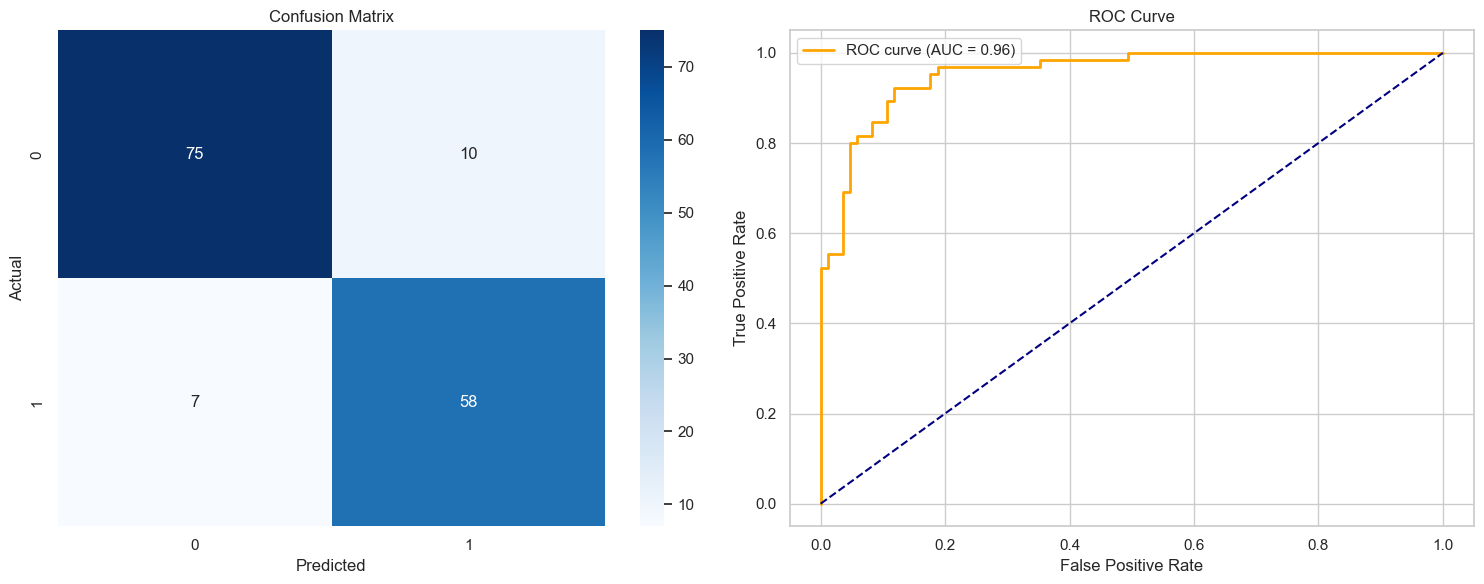

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Plot 2: ROC Curve
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {metrics.roc_auc_score(y_test, y_prob):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What loss function is minimized in Logistic Regression?**

*A: Log-loss (also called Binary Cross-Entropy Loss) is minimized using optimization algorithms like Gradient Descent.*

**Q2: Why is linear regression not suitable for classification?**

*A: Linear regression can predict values outside the [0, 1] range and is highly sensitive to outliers in classification labels.*

**Q3: What are odds and log-odds?**

*A: Odds represent ratio of success to failure p/(1-p). Log-odds is the natural log of odds, which scales predictions linearly from negative to positive infinity.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does Sigmoid function output range represent?**

*A: It outputs a probability value bounded strictly between 0 and 1.*

**Q2: What is the default probability threshold for binary classification?**

*A: 0.5 (50% probability).*

**Q3: Does logistic regression require scaling?**

*A: For convergence speed and coefficient interpretation regularization (L1/L2), scaling is highly recommended.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.